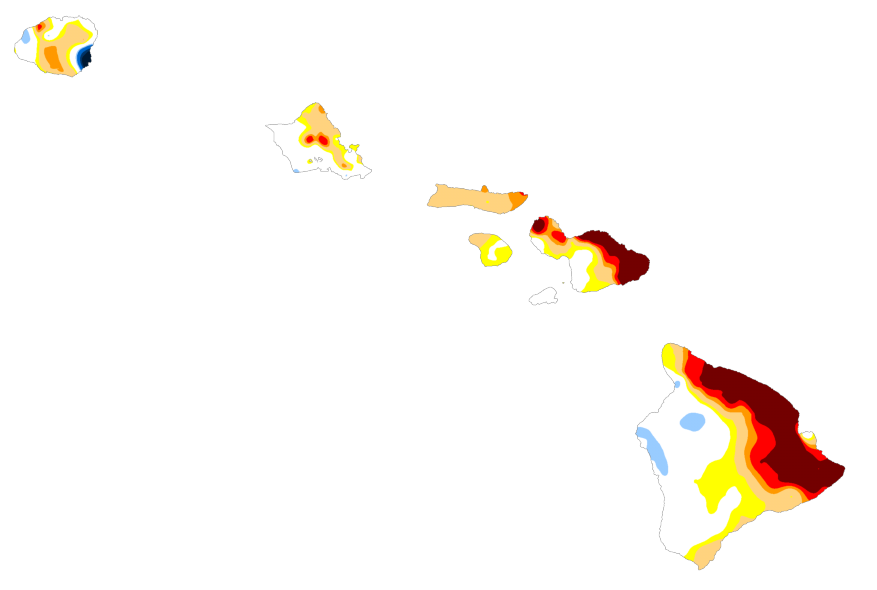

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -2, "#730000", "D4 Exceptional Drought"),
    (-2,   -1.6, "#FF0000", "D3 Extreme Drought"),
    (-1.6,   -1.3, "#FF9900", "D2 Severe Drought"),
    (-1.3,   -0.8, "#FFD37F", "D1 Moderate Drought"),
    (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
    (-0.5,    0.5, "#FFFFFF", "Near Normal"),
    ( 0.5,    0.8, "#99CCFF", "W0 Abnormally Wet"),
    ( 0.8,    1.3, "#0066CC", "W1 Moderately Wet"),
    ( 1.3,    1.6, "#0066CC", "W2 Very Wet"),
    ( 1.6,    2.0, "#003366", "W3 Extremely Wet"),
    ( 2.0,  np.inf, "#001933", "W4 Exceptionally Wet"),
]


with rasterio.open(f"spi_month_timescale012_statewide_data_map_2025_12.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
# with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
#     dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

# cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
# cbar.set_ticks(range(len(colors)))
# cbar.set_ticklabels(labels)
# cbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('../../public/climate-summary/spi12.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()


In [9]:
import rasterio
import numpy as np
import pandas as pd
with rasterio.open(f"spi_month_timescale012_statewide_data_map_2025_12.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

valid = np.isfinite(data)

pct = np.sum((data < -0.5) & valid) / np.sum(valid) * 100
print(f"{pct:.2f}%")

63.09%


In [28]:
import numpy as np
import pandas as pd
import rasterio

thresholds = [
    (-np.inf, -2,   "#730000", "D4 Exceptional Drought"),
    (-2,      -1.6, "#FF0000", "D3 Extreme Drought"),
    (-1.6,    -1.3, "#FF9900", "D2 Severe Drought"),
    (-1.3,    -0.8, "#FFD37F", "D1 Moderate Drought"),
    (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
    (-0.5,     0.5, "#FFFFFF", "Near Normal"),
    ( 0.5,     0.8, "#99CCFF", "W0 Abnormally Wet"),
    ( 0.8,     1.3, "#0066CC", "W1 Moderately Wet"),
    ( 1.3,     1.6, "#0066CC", "W2 Very Wet"),
    ( 1.6,     2.0, "#003366", "W3 Extremely Wet"),
    ( 2.0,   np.inf,"#001933", "W4 Exceptionally Wet"),
]
labels = [t[3] for t in thresholds]

rows = []

for m in range(1, 13):
    tif = f"/Users/cherryleheu/Documents/HCDP/Data/monthly/SPI/spi12_2025_{m:02d}.tif"
    with rasterio.open(tif) as src:
        data = src.read(1)
    valid = np.isfinite(data)

    total = valid.sum()
    out = {"month": f"{m:02d}"}

    for lo, hi, _, lab in thresholds:
        in_bin = (data >= lo) & (data < hi) & valid
        out[lab] = (in_bin.sum() / total) * 100.0

    rows.append(out)

df = pd.DataFrame(rows)
df


,month,D4 Exceptional Drought,D3 Extreme Drought,D2 Severe Drought,D1 Moderate Drought,D0 Abnormally Dry,Near Normal,W0 Abnormally Wet,W1 Moderately Wet,W2 Very Wet,W3 Extremely Wet,W4 Exceptionally Wet
0,01,1.011518,1.286187,3.063723,17.584024,13.072647,41.473629,12.552824,7.385505,1.828233,0.741710,0.00000
1,02,1.725449,3.187688,5.967019,17.170111,12.708389,39.430800,12.280933,5.744436,1.638986,0.146189,0.00000
2,03,0.931999,1.188959,2.523760,14.989079,12.795200,41.629541,15.512721,8.291462,1.892820,0.244459,0.00000
3,04,1.923030,3.416521,5.673252,17.542355,10.812097,30.968147,12.997642,14.386960,1.935184,0.344812,0.00000
4,05,2.873086,6.315998,9.889473,21.027630,10.254077,29.090259,15.155756,4.725973,0.667748,0.000000,0.00000
5,06,2.669949,6.087512,9.127969,20.743586,10.955161,28.280836,14.688367,5.828816,1.436543,0.181261,0.00000
6,07,2.312637,5.244060,10.322832,20.332797,11.224968,30.103166,14.182087,5.013143,1.233753,0.030557,0.00000
7,08,11.061764,9.926628,10.375612,20.580034,11.999319,33.657890,2.106374,0.292378,0.000000,0.000000,0.00000
8,09,12.858398,9.329717,8.921707,20.802617,11.576031,35.109017,1.397652,0.004861,0.000000,0.000000,0.00000
9,10,14.359181,8.904345,8.711973,18.804929,12.085783,34.378418,2.739051,0.016320,0.000000,0.000000,0.00000


In [26]:
df.to_csv("../../public/climate-summary/spi12_distribution_2025.csv", index=False)

In [35]:
import numpy as np
import pandas as pd
import rasterio

thresholds = [
    (-np.inf, -2,   "#730000", "D4 Exceptional Drought"),
    (-2,      -1.6, "#FF0000", "D3 Extreme Drought"),
    (-1.6,    -1.3, "#FF9900", "D2 Severe Drought"),
    (-1.3,    -0.8, "#FFD37F", "D1 Moderate Drought"),
    (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
    (-0.5,     0.5, "#FFFFFF", "Near Normal"),
    ( 0.5,     0.8, "#99CCFF", "W0 Abnormally Wet"),
    ( 0.8,     1.3, "#0066CC", "W1 Moderately Wet"),
    ( 1.3,     1.6, "#0066CC", "W2 Very Wet"),
    ( 1.6,     2.0, "#003366", "W3 Extremely Wet"),
    ( 2.0,   np.inf,"#001933", "W4 Exceptionally Wet"),
]
labels = [t[3] for t in thresholds]

rows = []

for m in range(1, 13):
    tif = f"/Users/cherryleheu/Documents/HCDP/Data/monthly/SPI/spi3_2025_{m:02d}.tif"
    with rasterio.open(tif) as src:
        data = src.read(1)
    valid = np.isfinite(data)

    total = valid.sum()
    out = {"month": f"{m:02d}"}

    for lo, hi, _, lab in thresholds:
        in_bin = (data >= lo) & (data < hi) & valid
        out[lab] = (in_bin.sum() / total) * 100.0

    rows.append(out)

df = pd.DataFrame(rows)
df


,month,D4 Exceptional Drought,D3 Extreme Drought,D2 Severe Drought,D1 Moderate Drought,D0 Abnormally Dry,Near Normal,W0 Abnormally Wet,W1 Moderately Wet,W2 Very Wet,W3 Extremely Wet,W4 Exceptionally Wet
0,01,0.000000,0.561491,6.059385,15.277638,12.942431,45.385318,14.037981,5.164888,0.570867,0.000000,0.000000
1,02,7.288625,12.130230,9.648833,14.780386,12.348298,41.371539,2.136584,0.283697,0.011806,0.000000,0.000000
2,03,0.000000,0.000000,2.012966,19.478580,12.441359,58.415948,6.470868,1.180278,0.000000,0.000000,0.000000
3,04,4.878413,12.708389,9.287354,14.994982,12.284058,40.262446,3.920370,1.663987,0.000000,0.000000,0.000000
4,05,0.524684,5.312814,8.081033,15.478691,8.952959,49.382429,7.664689,4.470403,0.132299,0.000000,0.000000
5,06,2.967536,4.839522,6.114250,10.744731,6.417045,35.542376,12.022932,13.947351,4.992656,2.194227,0.217374
6,07,0.294462,2.623766,5.934725,19.767486,13.174736,52.220096,3.369296,1.735866,0.406274,0.462875,0.010417
7,08,2.268537,7.681009,11.046485,28.665581,17.310744,29.695850,1.866082,0.824007,0.269113,0.164246,0.208346
8,09,1.438279,6.269120,13.481351,29.177069,20.897761,27.064098,0.533018,0.627815,0.176052,0.101395,0.234042
9,10,2.759191,5.523937,8.669262,30.691742,18.383724,31.262956,1.933795,0.329881,0.107298,0.131952,0.206262


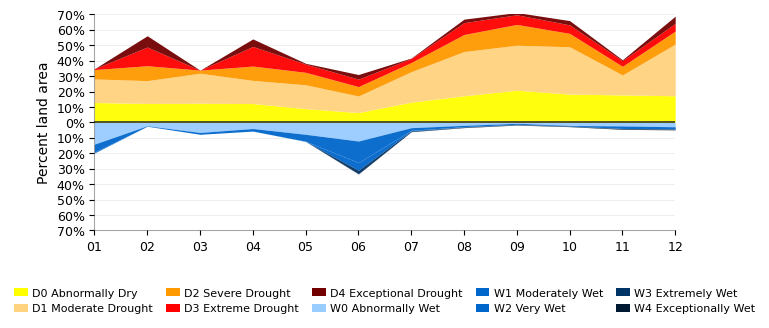

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, FuncFormatter

def diverging_stackplot(
    df,
    month_col="month",
    drought_labels=DROUGHT,
    wet_labels=WET,
    color_map=label2color,
    ylim=70,
    title=None,
    subtitle=None,
    figsize=(6.6, 3.6),   # good for 1-column PDF-ish layouts
):
    x = np.arange(1, 13)
    months = df[month_col].tolist()

    D = np.vstack([df[l].to_numpy(float) for l in drought_labels])
    W = np.vstack([df[l].to_numpy(float) for l in wet_labels])

    # Typography that usually prints well
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    fig, ax = plt.subplots(figsize=figsize)

    # Subtle grid behind areas
    ax.set_axisbelow(True)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.grid(axis="y", linewidth=0.6, alpha=0.25)

    # Drought (up)
    base = np.zeros_like(x, dtype=float)
    for lab, s in zip(drought_labels, D):
        ax.fill_between(
            x, base, base + s,
            color=color_map.get(lab),
            linewidth=0,
            alpha=0.95
        )
        base = base + s

    # Wet (down)
    base = np.zeros_like(x, dtype=float)
    for lab, s in zip(wet_labels, W):
        ax.fill_between(
            x, base, base - s,
            color=color_map.get(lab),
            linewidth=0,
            alpha=0.95
        )
        base = base - s

    # 0-line a touch stronger than grid
    ax.axhline(0, color="0.15", linewidth=1.1)

    # Axes
    ax.set_xlim(1, 12)
    ax.set_xticks(x)
    ax.set_xticklabels(months, rotation=0)  # try 20–30 if cramped
    ax.set_ylabel("Percent land area")

    ax.set_ylim(-ylim, ylim)

    # Show absolute values as percents
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{abs(v):.0f}%"))

    # Cleaner frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.35)
    ax.spines["bottom"].set_alpha(0.35)

    # # Title / subtitle
    # if title:
    #     ax.set_title(title, loc="left", pad=10, weight="bold")
    # if subtitle:
    #     ax.text(
    #         0.0, 1.02, subtitle,
    #         transform=ax.transAxes,
    #         ha="left", va="bottom",
    #         fontsize=9, color="0.35"
    #     )

    # Legend (compact, report-friendly)
    legend_items = (
        [Patch(facecolor=color_map[l], label=l.replace("D", "D").replace("W", "W")) for l in drought_labels] +
        [Patch(facecolor=color_map[l], label=l) for l in wet_labels]
    )

    ax.legend(
        handles=legend_items,
        ncol=5,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        handlelength=1.2,
        columnspacing=1.2,
        handletextpad=0.4,
        fontsize=8
    )

    fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.30)

    return fig, ax

# Example usage:
fig, ax = diverging_stackplot(df, title="SPI Category Area by Month", subtitle="Drought above 0, wetness below 0", ylim=70)
# fig.savefig("spi_diverging_stackplot.pdf", bbox_inches="tight")
plt.show()


In [16]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

shapefile = "../../public/shapefiles/islands.shp"   # has 'name' for county
raster_path = "spi_month_timescale012_statewide_data_map_2025_12.tif" 

# one polygon per county
gdf = gpd.read_file(shapefile).dissolve(by="name", as_index=False).reset_index(drop=True)

threshold = -0.5

with rasterio.open(raster_path) as src:
    arr = src.read(1, masked=True)
    nodata = src.nodata
    affine = src.transform

# boolean raster: 1 where condition is met, 0 elsewhere (masked nodata stays masked)
cond = (arr < threshold).astype("uint8")
cond = np.ma.array(cond, mask=arr.mask)

# zonal sums of condition pixels and counts of valid pixels
sum_stats = zonal_stats(
    gdf, cond.filled(0), affine=affine,
    stats=["sum"], nodata=0, all_touched=False
)
cnt_stats = zonal_stats(
    gdf, np.where(arr.mask, 0, 1).astype("uint8"), affine=affine,
    stats=["sum"], nodata=0, all_touched=False
)

gdf["n_lt_thr"] = [s["sum"] or 0 for s in sum_stats]
gdf["n_valid"]  = [c["sum"] or 0 for c in cnt_stats]

gdf["pct_-0.5"] = np.where(
    gdf["n_valid"] > 0,
    100.0 * gdf["n_lt_thr"] / gdf["n_valid"],
    np.nan
)
gdf["pct_-0.5"] = gdf["pct_-0.5"].round(2)

gdf[["name", "pct_-0.5"]].to_csv("island_spi12_below_neg0.5_2025.csv", index=False)


Hawaii      pct_lt_-0_5= 60.84  n_lt=  109317  n_valid=  179685
Kahoolawe   pct_lt_-0_5= 82.50  n_lt=   27565  n_valid=   33413
Kauai       pct_lt_-0_5= 56.39  n_lt=   14444  n_valid=   25615
Lanai       pct_lt_-0_5= 81.95  n_lt=    5429  n_valid=    6625
Maui        pct_lt_-0_5=  0.00  n_lt=       0  n_valid=    2245
Molokai     pct_lt_-0_5=100.00  n_lt=   12334  n_valid=   12334
Oahu        pct_lt_-0_5= 44.85  n_lt=   12583  n_valid=   28054


Hawaii
Kahoolawe
Kauai
Lanai
Maui
Molokai
Oahu
